In [20]:
from peft import PeftModel, PeftConfig, LoraConfig, get_peft_model
from torch.utils.data import Dataset, DataLoader
from peft.utils.other import fsdp_auto_wrap_policy
from accelerate import Accelerator
from confit.data_utils import Mutation_Set, split_train, sample_data
from transformers import EsmForMaskedLM, EsmTokenizer, EsmConfig
import pandas as pd


In [22]:
def evaluate(model, testloader, tokenizer, accelerator, istest=False):
    model.eval()
    seq_list = []
    score_list = []
    gscore_list = []
    with torch.no_grad():
        for step, data in enumerate(testloader):
            seq, mask = data[0], data[1]
            wt, wt_mask = data[2], data[3]
            pos = data[4]
            golden_score = data[5]
            pid = data[6]
            if istest:
                pid = pid.cuda()
                pid = accelerator.gather(pid)
                for s in pid:
                    seq_list.append(s.cpu())

            score, logits = compute_score(model, seq, mask, wt, pos, tokenizer)

            score = score.cuda()
            score = accelerator.gather(score)
            golden_score = accelerator.gather(golden_score)
            score = np.asarray(score.cpu())
            golden_score = np.asarray(golden_score.cpu())
            score_list.extend(score)
            gscore_list.extend(golden_score)
    score_list = np.asarray(score_list)
    gscore_list = np.asarray(gscore_list)
    sr = spearman(score_list, gscore_list)

    if istest:
        seq_list = np.asarray(seq_list)

        return sr, score_list, seq_list
    else:
        return sr

In [46]:
accelerator = Accelerator()

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [47]:
datasetname = "mgrb_filtered_better_smaller_lora"

In [48]:
basemodel = EsmForMaskedLM.from_pretrained(f'facebook/esm1v_t33_650M_UR90S_1')
tokenizer = EsmTokenizer.from_pretrained(f'facebook/esm1v_t33_650M_UR90S_1')

model = PeftModel.from_pretrained(basemodel, f"checkpoint/{datasetname}/seed1")
model = accelerator.prepare(model)

Some weights of EsmForMaskedLM were not initialized from the model checkpoint at facebook/esm1v_t33_650M_UR90S_1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [51]:
test_csv = pd.read_csv(f'data/{datasetname}/test.csv')
all_data = pd.read_csv(f'data/{datasetname}/data.csv')
testset = Mutation_Set(data=test_csv, fname=datasetname,  tokenizer=tokenizer)
testloader = DataLoader(testset, batch_size=2, collate_fn=testset.collate_fn)
testloader = accelerator.prepare(testloader)

In [52]:
%%time
# ------------------ imports ------------------
import torch, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from scipy.stats import spearmanr as spearman   # same alias your code expects

# ------------------ helper functions ------------------
def compute_score(model, seq, mask, wt, pos, tokenizer):
    """
    Compute a mutational proxy score using the masked‑marginal probability
    Parameters
    ----------
    model : torch.nn.Module
    seq   : LongTensor (B, L) – input sequence token IDs
    mask  : LongTensor (B, L) – attention mask
    wt    : LongTensor (B, L) – wild‑type sequence token IDs
    pos   : LongTensor (B,)   – mutation positions (0‑indexed wrt seq)
    tokenizer : transformers tokenizer with .mask_token_id
    Returns
    -------
    scores : Tensor (B,) – proxy scores
    logits : Tensor (B, L, V) – full model logits
    """
    device = seq.device
    mask_seq = seq.clone()
    m_id = tokenizer.mask_token_id

    # put a [MASK] at each mutant position
    for i in range(seq.size(0)):
        mask_seq[i, pos[i] + 1] = m_id     # +1 if your model expects BOS

    out = model(mask_seq, mask, output_hidden_states=True)
    logits = out.logits
    log_probs = torch.log_softmax(logits, dim=-1)

    scores = torch.zeros(seq.size(0), device=device)
    for i in range(seq.size(0)):
        m = pos[i] + 1
        scores[i] = (
            log_probs[i, m, seq[i, m]]   # log P(mutant AA)
            - log_probs[i, m, wt[i, m]]  # log P(wild‑type AA)
        )

    return scores, logits


def evaluate(model, testloader, tokenizer, accelerator, istest=False):
    model.eval()
    seq_list, score_list, gscore_list = [], [], []

    with torch.no_grad():
        for seq, mask, wt, wt_mask, pos, golden_score, pid in testloader:
            if istest:
                pid = accelerator.gather(pid.cuda())
                seq_list.extend(pid.cpu().tolist())

            score, _ = compute_score(model, seq, mask, wt, pos, tokenizer)

            score = accelerator.gather(score.cuda())
            golden_score = accelerator.gather(golden_score)

            score_list.extend(score.cpu().numpy())
            gscore_list.extend(golden_score.cpu().numpy())

    sr = spearman(score_list, gscore_list)

    if istest:
        return sr, np.asarray(score_list), np.asarray(seq_list)
    return sr

# ------------------ run evaluation ------------------
spearman_r = evaluate(model, testloader, tokenizer, accelerator)
print(f"Spearman ρ on test set: {spearman_r:}")

TypeError: unsupported format string passed to SpearmanrResult.__format__

In [53]:
spearman_r

SpearmanrResult(correlation=0.6232360127969367, pvalue=9.70398106039106e-13)

In [55]:
%%time
# --------------------------------------------------------------------
# 1)  Evaluate and keep the true scores as well
# --------------------------------------------------------------------
from torch.utils.data import DataLoader
import numpy as np
from scipy.stats import spearmanr as spearman

def evaluate_full(model, testloader, tokenizer, accelerator, quantile=0.85):
    """
    Returns:
        rho              : float               – Spearman ρ over the full set
        pred_scores      : numpy.ndarray (N,) – model scores
        true_scores      : numpy.ndarray (N,) – experimental / golden scores
        seq_ids          : numpy.ndarray (N,) – protein or mutation IDs
    """
    model.eval()
    seq_ids, pred_scores, true_scores = [], [], []

    with torch.no_grad():
        for seq, mask, wt, wt_mask, pos, gscore, pid in testloader:
            # forward pass
            scores, _ = compute_score(model, seq, mask, wt, pos, tokenizer)

            # gather across distributed devices
            scores       = accelerator.gather(scores.cuda()).cpu().numpy()
            gscore       = accelerator.gather(gscore).cpu().numpy()
            pid          = accelerator.gather(pid.cuda()).cpu().numpy()

            pred_scores.extend(scores)
            true_scores.extend(gscore)
            seq_ids.extend(pid)

    pred_scores = np.asarray(pred_scores)
    true_scores = np.asarray(true_scores)
    seq_ids     = np.asarray(seq_ids)

    # Spearman on the whole set
    rho = spearman(pred_scores, true_scores)
    rho = rho.correlation if hasattr(rho, "correlation") else rho[0]

    return rho, pred_scores, true_scores, seq_ids


# --------------------------------------------------------------------
# 2)  Outlier‑ranking utilities
# --------------------------------------------------------------------
from sklearn.metrics import average_precision_score, roc_auc_score

def outlier_metrics(pred, true, top_quantile=0.85, ks=(5, 10, 20)):
    """
    Treats sequences whose true score ≥ Q(top_quantile) as 'positive outliers'.

    Returns a dict with:
        threshold, n_outliers, AP, ROC‑AUC, precision@k, recall@k ...
    """
    threshold      = np.quantile(true, top_quantile)
    y_true         = (true >= threshold).astype(int)        # 1 = outlier
    n_positives    = y_true.sum()

    # ranking indices (highest model score first)
    order          = np.argsort(-pred)
    y_true_sorted  = y_true[order]

    # Average Precision & ROC‑AUC
    ap   = average_precision_score(y_true, pred)
    auc  = roc_auc_score(y_true, pred)

    # Precision@k / Recall@k
    prec = {}
    rec  = {}
    for k in ks:
        topk          = y_true_sorted[:k]
        tp            = topk.sum()
        prec[k]       = tp / k
        rec[k]        = tp / n_positives if n_positives else 0.0

    return {
        "threshold"   : threshold,
        "n_outliers"  : int(n_positives),
        "AP"          : ap,
        "ROC‑AUC"     : auc,
        "precision@"  : prec,
        "recall@"     : rec,
    }


def pretty_print(metrics):
    print(f"▶  Outlier threshold (top 15 %): {metrics['threshold']:.4f}")
    print(f"▶  # true outliers           : {metrics['n_outliers']}")
    print(f"\nRanking quality on outliers")
    print(f"  • Average Precision (AP) : {metrics['AP']:.4f}")
    print(f"  • ROC‑AUC                : {metrics['ROC‑AUC']:.4f}")
    for k in metrics['precision@']:
        print(f"  • Precision@{k:<2}           : {metrics['precision@'][k]:.3f}"
              f"   |   Recall@{k:<2}: {metrics['recall@'][k]:.3f}")


# --------------------------------------------------------------------
# 3)  Build loader, run evaluation + outlier metrics
# --------------------------------------------------------------------
import pandas as pd

test_csv   = pd.read_csv(f"data/{datasetname}/test.csv")
testset    = Mutation_Set(data=test_csv,
                          fname=datasetname,
                          tokenizer=tokenizer)
testloader = DataLoader(testset,
                        batch_size=2,
                        collate_fn=testset.collate_fn)
testloader = accelerator.prepare(testloader)

rho, pred_scores, true_scores, seq_ids = evaluate_full(
        model, testloader, tokenizer, accelerator)

print(f"Spearman ρ on full set      : {rho:.4f}\n")

metrics = outlier_metrics(pred_scores, true_scores, top_quantile=0.85)
pretty_print(metrics)

Spearman ρ on full set      : 0.6232

▶  Outlier threshold (top 15 %): 2.5690
▶  # true outliers           : 16

Ranking quality on outliers
  • Average Precision (AP) : 0.4456
  • ROC‑AUC                : 0.7590
  • Precision@5            : 0.400   |   Recall@5 : 0.125
  • Precision@10           : 0.500   |   Recall@10: 0.312
  • Precision@20           : 0.400   |   Recall@20: 0.500
CPU times: user 27.4 s, sys: 1.22 s, total: 28.6 s
Wall time: 28.7 s


In [56]:
%%time
import numpy as np
from itertools import combinations
from collections import defaultdict

# ------------------------------------------------------------
# 1.  Get the predictions & true fitness values one more time
# ------------------------------------------------------------
rho, pred_scores, true_scores, seq_ids = evaluate_full(
        model, testloader, tokenizer, accelerator)

# ------------------------------------------------------------
# 2.  Pair‑wise discrimination test
# ------------------------------------------------------------
def pairwise_accuracy(pred, true, deltas=(0.10, 0.01), max_pairs=250_000, rng=None):
    """
    For each delta in `deltas`, compute the fraction of pairs (i, j) such that
        |true_i - true_j| >= delta
    **and** the predicted ranking agrees with the true ranking.

    Parameters
    ----------
    pred, true : 1‑D numpy arrays (same length)
    deltas     : iterable of positive numbers
    max_pairs  : soft cap to keep runtime reasonable
    rng        : np.random.Generator, optional

    Returns
    -------
    dict { delta : (accuracy, n_pairs) }
    """
    rng = rng or np.random.default_rng(42)
    n   = len(true)

    # if the set is large, subsample pairs to cap complexity
    all_idx = np.arange(n)
    est_max = n * (n-1) // 2
    if est_max > max_pairs:
        combs = rng.choice(est_max, size=max_pairs, replace=False)
        # map the integer back to (i, j) via Cantor pairing trick
        #   k = i*n + j - i*(i+1)//2 - i - 1 with i<j
        pairs = []
        for k in combs:
            # invert Cantor pairing to get (i, j)
            i = int((2*n - 1 - np.sqrt((2*n - 1)**2 - 8*k)) // 2)
            j = k + i + 1 - i*(2*n - i - 1)//2
            pairs.append((i, j))
    else:
        pairs = combinations(all_idx, 2)

    # tallies
    hit   = defaultdict(int)
    total = defaultdict(int)

    # loop once through sampled pairs
    for i, j in pairs:
        dt = abs(true[i] - true[j])
        dp = pred[i] - pred[j]
        sign_true = np.sign(true[i] - true[j])
        sign_pred = np.sign(dp)

        for d in deltas:
            if dt >= d:
                total[d] += 1
                hit[d]   += (sign_true == sign_pred)

    return {d: (hit[d] / total[d] if total[d] else np.nan, total[d]) for d in deltas}


# ------------------------------------------------------------
# 3.  Run the test and print a concise report
# ------------------------------------------------------------
metrics = pairwise_accuracy(pred_scores, true_scores, deltas=(1.0, 0.1, 0.01))

print("Pair‑wise discrimination accuracy\n"
      "================================")
for d, (acc, n) in metrics.items():
    if np.isnan(acc):
        print(f"Δ ≥ {d:4.2f} :  not enough pairs")
    else:
        print(f"Δ ≥ {d:4.2f} :  accuracy = {acc:.3f}  (N = {n})")

Pair‑wise discrimination accuracy
Δ ≥ 1.00 :  accuracy = 0.900  (N = 860)
Δ ≥ 0.10 :  accuracy = 0.758  (N = 4892)
Δ ≥ 0.01 :  accuracy = 0.733  (N = 5498)
CPU times: user 27.4 s, sys: 1.2 s, total: 28.6 s
Wall time: 28.7 s


In [58]:
%%time
import numpy as np, pandas as pd
from collections import defaultdict
from itertools import combinations
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# 1.  Evaluate once and keep the mutation positions
# ------------------------------------------------------------
def evaluate_with_pos(model, loader, tokenizer, accelerator):
    """
    Returns:
        pred_scores  : numpy (N,)
        true_scores  : numpy (N,)
        positions    : numpy (N,)  -- mutation position for each variant
    """
    model.eval()
    preds, trues, poss = [], [], []

    with torch.no_grad():
        for seq, mask, wt, wt_mask, pos, gscore, pid in loader:
            scores, _ = compute_score(model, seq, mask, wt, pos, tokenizer)

            preds.extend(accelerator.gather(scores.cuda()).cpu().numpy())
            trues.extend(accelerator.gather(gscore).cpu().numpy())

            # ▶︎ ensure `pos` is a tensor and on the right device
            if not torch.is_tensor(pos):
                pos = torch.as_tensor(pos)
            pos = pos.to(scores.device)              # ▶︎ move to GPU/CPU matching scores

            poss.extend(accelerator.gather(pos).cpu().numpy())   # ▶︎ gather then numpy

    return np.asarray(preds), np.asarray(trues), np.asarray(poss)



# ------------------------------------------------------------
# 2.  Pair‑wise failure clustering
# ------------------------------------------------------------
def failure_by_position(pred, true, pos, delta=0.10, max_pairs=250_000, seed=42):
    """
    Count how often each mutation position takes part in a ranking failure.

    Parameters
    ----------
    delta      : minimum true‑fitness gap to qualify a pair
    max_pairs  : cap on pair sampling to keep runtime reasonable
    Returns
    -------
    DataFrame  : position | failures | total_pairs | failure_rate
    """
    rng       = np.random.default_rng(seed)
    n         = len(true)
    total_all = n * (n - 1) // 2

    # choose which pairs to test
    if total_all <= max_pairs:
        pair_idx = np.array(list(combinations(range(n), 2)))
    else:
        # uniform subsample of Cantor‑encoded pair indices
        k        = rng.choice(total_all, size=max_pairs, replace=False)
        # inverse Cantor pairing to (i, j)
        i = (np.ceil((np.sqrt(8*k + 1) - 1) / 2) - 1).astype(int)
        j = k - i*(2*n - i - 1)//2 + i + 1
        pair_idx = np.stack([i, j], axis=1)

    fail_cnt  = defaultdict(int)
    total_cnt = defaultdict(int)

    for i, j in pair_idx:
        if abs(true[i] - true[j]) < delta:
            continue
        total_cnt[pos[i]] += 1
        total_cnt[pos[j]] += 1
        if np.sign(pred[i] - pred[j]) != np.sign(true[i] - true[j]):
            fail_cnt[pos[i]] += 1
            fail_cnt[pos[j]] += 1

    data = {
        "position"     : [],
        "failures"     : [],
        "total_pairs"  : [],
        "failure_rate" : []
    }
    for p in total_cnt:
        data["position"].append(int(p))
        data["failures"].append(fail_cnt.get(p, 0))
        data["total_pairs"].append(total_cnt[p])
        data["failure_rate"].append(fail_cnt.get(p, 0) / total_cnt[p])

    df = pd.DataFrame(data).sort_values("failure_rate", ascending=False)
    return df


# ------------------------------------------------------------
# 3.  Run and show the worst‑offending positions
# ------------------------------------------------------------

test_csv   = pd.read_csv(f"data/{datasetname}/test.csv")
testset    = Mutation_Set(test_csv, datasetname, tokenizer)
loader     = DataLoader(testset, batch_size=2, collate_fn=testset.collate_fn)
loader     = accelerator.prepare(loader)

pred, true, pos = evaluate_with_pos(model, loader, tokenizer, accelerator)
df_fail = failure_by_position(pred, true, pos,
                              delta=1.0,   # rank gap to count
                              max_pairs=2_00_000)

top = df_fail.head(20)
display(top)            # Jupyter will render a nice table

print("\nTop 20 positions by failure‑rate ↑ (Δ ≥ 1.0)")

,position,failures,total_pairs,failure_rate
0,42,32,73,0.438356
18,31,17,47,0.361702
25,30,3,19,0.157895
2,37,27,172,0.156977
17,38,8,55,0.145455
16,28,9,62,0.145161
3,22,13,94,0.138298
20,20,2,15,0.133333
10,36,5,43,0.116279
19,35,2,18,0.111111



Top 20 positions by failure‑rate ↑ (Δ ≥ 1.0)
CPU times: user 27.4 s, sys: 1.21 s, total: 28.6 s
Wall time: 28.7 s


In [62]:
del model
del tokenizer

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Loading tokenizer …


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading 650 M‑param base model …


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at facebook/esm1v_t33_650M_UR90S_1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Step   18 | β 276.6 | best score  -2.559 | accept rate 42.71%


Simulated annealing:  95%|█████████▌| 19/20 [04:39<00:14, 14.71s/it]

Step   19 | β 332.6 | best score  -2.559 | accept rate 42.60%


Simulated annealing: 100%|██████████| 20/20 [04:54<00:00, 14.71s/it]

Step   20 | β 400.0 | best score  -2.559 | accept rate 42.03%

Final acceptance rate: 42.03%

Top 5 variants vs. WT:

#1: score  -2.559


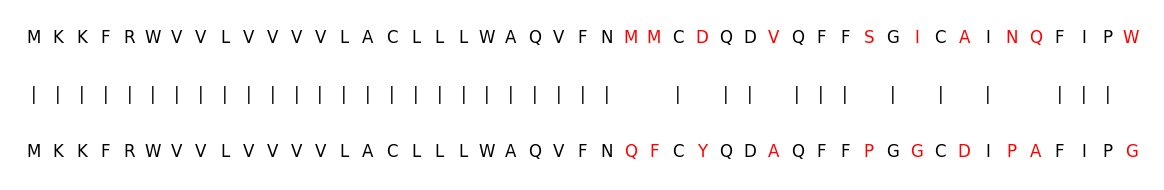


#2: score  -2.620


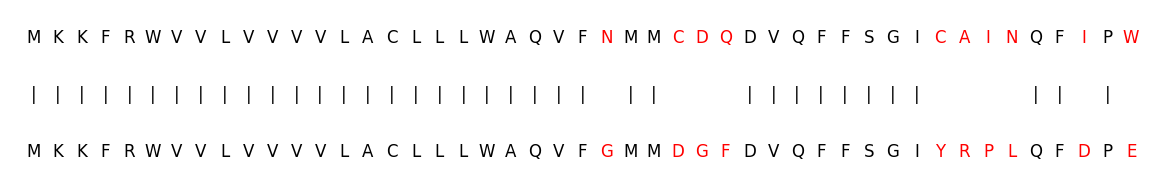


#3: score  -2.641


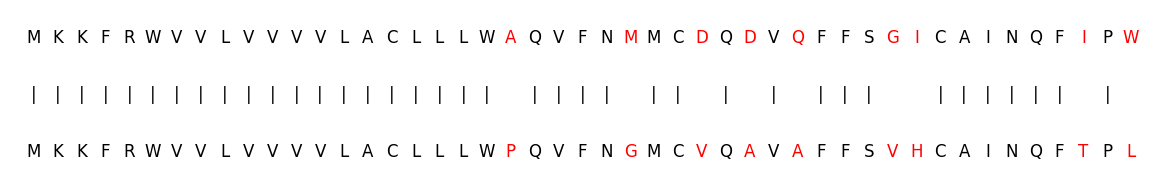


#4: score  -2.646


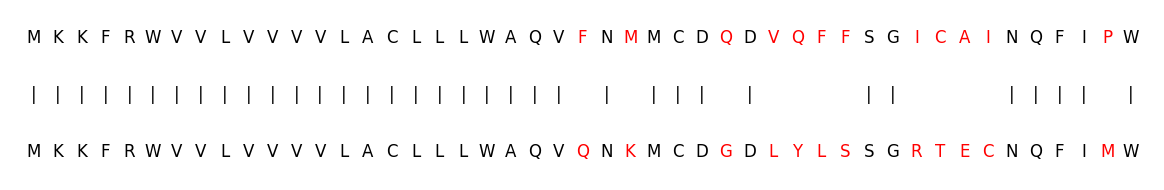


#5: score  -2.677


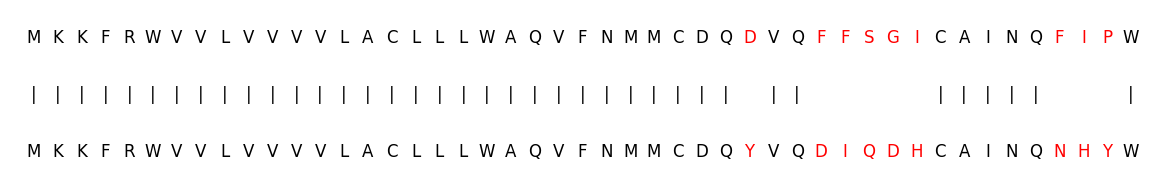

In [71]:
#!/usr/bin/env python
"""
ESM‑1v (650 M) + LoRA scorer inside a simulated‑annealing MCMC search
====================================================================

• Loads a LoRA‑fine‑tuned ESM‑1v masked‑LM with 🤗 Transformers + PEFT  
• Performs batched masked‑marginal scoring of sequences  
• Explores sequence space with a simple simulated‑annealing Monte‑Carlo search  
• Highlights mutations in red when printing the top variants vs. the wild type

Launch on 1 GPU
---------------
$ python mcmc_esm1v_lora.py

Launch on *n* GPUs with mixed precision (recommended for 2+ GPUs)
----------------------------------------------------------------
$ accelerate launch --multi_gpu --mixed_precision fp16 mcmc_esm1v_lora.py
"""

# ---------------------------------------------------------------------
# 0.  Imports & global objects
# ---------------------------------------------------------------------
import random
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import EsmForMaskedLM, EsmTokenizer
from peft import PeftModel
from accelerate import Accelerator

# ---------- accelerate handles device, DDP & autocast ----------
accelerator = Accelerator()                 # obeys CLI flags when using `accelerate launch`
device      = accelerator.device            # torch.device("cuda", idx) or cpu


# ---------------------------------------------------------------------
# 1.  Load tokenizer, base model, and LoRA weights
# ---------------------------------------------------------------------
MODEL_NAME     = "facebook/esm1v_t33_650M_UR90S_1"
LORA_CHECKPOINT= "checkpoint/mgrb_filtered_better_smaller_lora/seed1"     # <-- adapt as needed

print("Loading tokenizer …")
tokenizer = EsmTokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case=False,
    return_attention_mask=True
)
mask_token_id = tokenizer.mask_token_id

print("Loading 650 M‑param base model …")
base_model = EsmForMaskedLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True   # ESM models need this in 2025‑era transformers
)

print(f"Applying LoRA weights from “{LORA_CHECKPOINT}”")
model = PeftModel.from_pretrained(base_model, LORA_CHECKPOINT)
model = accelerator.prepare(model).eval()   # moves to device, wraps in DDP if multi‑GPU


# ---------------------------------------------------------------------
# 2.  Scoring: masked marginal log‑probabilities, batched
# ---------------------------------------------------------------------
@torch.no_grad()
def score_batch_masked_marginals(seqs):
    """
    Returns: numpy array (N,) – average log‑prob / position
    """
    enc        = tokenizer(seqs, return_tensors='pt', padding=True)
    input_ids  = enc['input_ids'].to(device)           # (N, L)
    N, L       = input_ids.shape
    K          = L - 2                                 # ignore BOS/EOS for scoring

    # create K * N masked sequences
    masked = input_ids.unsqueeze(0).expand(K, -1, -1).reshape(-1, L).clone()
    for idx, pos in enumerate(range(1, L - 1)):        # 1 … L‑2 (inclusive)
        start, end           = idx * N, (idx + 1) * N
        masked[start:end, pos] = mask_token_id

    with accelerator.autocast():                       # fp16/bf16 if available
        logits     = model(masked).logits
        log_probs  = torch.log_softmax(logits, dim=-1) # (K · N, L, V)

    scores = torch.zeros(N, device=device)
    for idx, pos in enumerate(range(1, L - 1)):
      block     = log_probs[idx * N:(idx + 1) * N, pos, :]   # (N, V)
      true_ids  = input_ids[:, pos].unsqueeze(1)             # (N, 1)
      scores   += block.gather(1, true_ids).squeeze(1)       # add log‑p of each true token

    return (scores / K).cpu().numpy()


# ---------------------------------------------------------------------
# 3.  Sequence mutation helper
# ---------------------------------------------------------------------
CONSTANT_PREFIX = 20 # residues [0:CONSTANT_PREFIX] stay fixed

# allowable single‑letter amino‑acid tokens in ESM tokenizer
AA_TOKENS = [tok for tok in tokenizer.get_vocab()
             if len(tok) == 1 and tok.isupper()]

def mutate_sequence(seq, max_mutations=3):
    """
    Randomly mutate 1…max_mutations positions *after* the constant prefix.
    """
    if len(seq) <= CONSTANT_PREFIX:
        raise ValueError("Sequence shorter than CONSTANT_PREFIX")
    mutable = list(range(CONSTANT_PREFIX, len(seq)))
    n_mut   = random.randint(1, min(max_mutations, len(mutable)))
    positions = random.sample(mutable, n_mut)

    seq_list = list(seq)
    for pos in positions:
        choices = [aa for aa in AA_TOKENS if aa != seq_list[pos]]
        seq_list[pos] = random.choice(choices)
    return ''.join(seq_list)


# ---------------------------------------------------------------------
# 4.  MCMC with geometric β schedule (simulated annealing)
# ---------------------------------------------------------------------
def mcmc_simulated_annealing(
    start_seq,
    steps         = 2000,
    beta_start    = 2.0,
    beta_end      = 50.0,
    max_mutations = 2,
    num_chains    = 256,
    print_interval= 100
):
    """
    Returns:
        best_seqs   : list[str] (num_chains,)
        best_scores : list[float] (num_chains,)
    """
    # initialise chains
    chains       = [start_seq] * num_chains
    scores       = score_batch_masked_marginals(chains)
    best_seqs    = chains.copy()
    best_scores  = scores.copy()
    total_accept = 0

    # geometric β schedule
    betas = beta_start * (beta_end / beta_start) ** (
            np.arange(1, steps + 1) / steps)

    for step, beta in enumerate(tqdm(betas, desc="Simulated annealing"), start=1):
        proposals    = [mutate_sequence(seq, max_mutations) for seq in chains]
        prop_scores  = score_batch_masked_marginals(proposals)
        
        base_acc = 0.90   
        deltas = prop_scores - scores # global accuracy
        logit    = beta * deltas
        # logistic σ(x) = 1 / (1 + exp(-x))
        sigma    = 1.0 / (1.0 + np.exp(-logit))
        
        probs    = base_acc * sigma + (1.0 - base_acc) * (1.0 - sigma)
        accept   = np.random.rand(num_chains) < probs

        for i, ok in enumerate(accept):
            if ok:
                chains[i], scores[i] = proposals[i], prop_scores[i]
                total_accept += 1
                if scores[i] > best_scores[i]:
                    best_scores[i], best_seqs[i] = scores[i], chains[i]

        if step % print_interval == 0:
            acc_rate = total_accept / (step * num_chains)
            print(f"Step {step:4d} | β {beta:5.1f} | "
                  f"best score {best_scores.max():7.3f} | "
                  f"accept rate {acc_rate:5.2%}")

    print(f"\nFinal acceptance rate: "
          f"{total_accept / (steps * num_chains):.2%}")
    return best_seqs, best_scores


# ---------------------------------------------------------------------
# 5.  Pretty diff of two sequences
# ---------------------------------------------------------------------
def plot_sequence_diff(seq1, seq2, figsize=(None, 2), font_size=12):
    """
    Show WT vs. variant, highlighting mutations in red.
    """
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must be the same length")

    length      = len(seq1)
    width       = figsize[0] or length * 0.3
    matches     = [a == b for a, b in zip(seq1, seq2)]

    fig, ax = plt.subplots(figsize=(width, figsize[1]))
    ax.set_axis_off()
    ax.set_xlim(-1, length)
    ax.set_ylim(-0.5, 2.5)

    for i, (a, b, same) in enumerate(zip(seq1, seq2, matches)):
        color = 'black' if same else 'red'
        ax.text(i, 2, a, color=color, ha='center', va='center', fontsize=font_size)
        ax.text(i, 1, '|' if same else ' ', ha='center', va='center', fontsize=font_size)
        ax.text(i, 0, b, color=color, ha='center', va='center', fontsize=font_size)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 6.  RUNIT
# ---------------------------------------------------------------------

# wild‑type sequence (must be longer than CONSTANT_PREFIX)
wt_seq = "MKKFRWVVLVVVVLACLLLWAQVFNMMCDQDVQFFSGICAINQFIPW"
# Sanity‑check WT score
wt_score = score_batch_masked_marginals([wt_seq])[0]
print(f"WT average log‑prob per position: {wt_score:7.3f}\n")

# Run the Monte‑Carlo search
best_seqs, best_scores = mcmc_simulated_annealing(
    start_seq     = wt_seq,
    steps         = 20,
    beta_start    = 10.0,
    beta_end      = 400.0,
    max_mutations = 2,
    num_chains    = 32,
    print_interval= 1
)

# Display the top 5 variants
top_idx = np.argsort(best_scores)[-5:][::-1]
print("\nTop 5 variants vs. WT:")
for rank, idx in enumerate(top_idx, start=1):
  var, score = best_seqs[idx], best_scores[idx]
  print(f"\n#{rank}: score {score:7.3f}")
  plot_sequence_diff(wt_seq, var, figsize=(len(wt_seq) * 0.25, 2), font_size=12)





In [72]:
import numpy as np, textwrap, json, os

# --- configuration ----------------------------------------------------
out_file   = "best_variants.fasta"   # will be created in the current dir
top_n      = 20                      # how many sequences to write
line_len   = 60                      # FASTA line wrap
# ----------------------------------------------------------------------

# best_seqs and best_scores must already exist in the workspace
try:
    best_seqs
    best_scores
except NameError:
    raise RuntimeError("Run the MCMC first so `best_seqs` and `best_scores` exist")

# pick the top‑N indices
top_idx = np.argsort(best_scores)[-top_n:][::-1]

with open(out_file, "w") as fh:
    for rank, idx in enumerate(top_idx, start=1):
        seq   = best_seqs[idx]
        score = best_scores[idx]
        header = f">variant_{rank:02d}|score={score:.4f}"
        fh.write(header + "\n")
        fh.write("\n".join(textwrap.wrap(seq, line_len)) + "\n")

print(f"Wrote {top_n} sequences to {out_file}")

Wrote 20 sequences to best_variants.fasta


In [ ]:
import os
from IPython.display import Image, display

# The 'datasetname' variable is expected to be defined in a previous cell.
# We'll use it to run the comparison script.
if 'datasetname' not in locals():
    # Provide a default if running this cell standalone
    datasetname = "mgrb_filtered_better_smaller_lora"
    print(f"Warning: 'datasetname' not found, using default: {datasetname}")


output_image_path = "scoring_correlation.png"
command = f"""
accelerate launch score_comparison.py \\
    --datasetname {datasetname} \\
    --output_plot {output_image_path}
"""

print("Running scoring comparison script. This may take a few minutes...")
# Using os.system to see live output from the script
os.system(command)
print("-" * 50)


# Display the resulting plot
if os.path.exists(output_image_path):
    print(f"Script finished. Displaying plot from '{output_image_path}'")
    display(Image(filename=output_image_path))
else:
    print(f"Error: Output plot not found at '{output_image_path}'. Please check the script's output for errors.")